# Notebook 4: Technical Analysis

Calculate technical indicators (RSI, MACD, Bollinger Bands) for trading signals.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_single_stock
from src.data_cleaner import clean_data
from config.config import PRIMARY_STOCK, RSI_PERIOD, MACD_FAST, MACD_SLOW, MACD_SIGNAL, BB_PERIOD, BB_STD

print('✅ All imports successful!')


✅ All imports successful!


## Load Data

In [2]:
# Load and clean data
raw_data = load_single_stock(PRIMARY_STOCK)
data = clean_data(raw_data, PRIMARY_STOCK)

print(f'Data loaded: {len(data)} trading days')


✅ Successfully downloaded 252 records for MSFT

Cleaning MSFT data...
Missing values before: 0
Missing values after: 0
✅ Cleaned data shape: (252, 5)
Data loaded: 252 trading days


## Calculate Technical Indicators

In [3]:
# Create a copy for technical indicators
tech_data = data.copy()
# If columns are MultiIndex (e.g., ('Close','MSFT')), flatten to top-level names
import pandas as _pd
if isinstance(tech_data.columns, _pd.MultiIndex):
    tech_data.columns = [c[0] for c in tech_data.columns]

# 1. Relative Strength Index (RSI)
delta = tech_data['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=RSI_PERIOD).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=RSI_PERIOD).mean()
rs = gain / loss
tech_data['RSI'] = 100 - (100 / (1 + rs))

# 2. MACD (Moving Average Convergence Divergence)
exp1 = tech_data['Close'].ewm(span=MACD_FAST, adjust=False).mean()
exp2 = tech_data['Close'].ewm(span=MACD_SLOW, adjust=False).mean()
tech_data['MACD'] = exp1 - exp2
tech_data['Signal_Line'] = tech_data['MACD'].ewm(span=MACD_SIGNAL, adjust=False).mean()
tech_data['MACD_Histogram'] = tech_data['MACD'] - tech_data['Signal_Line']

# 3. Bollinger Bands
tech_data['SMA'] = tech_data['Close'].rolling(window=BB_PERIOD).mean()
tech_data['STD'] = tech_data['Close'].rolling(window=BB_PERIOD).std()
tech_data['BB_Upper'] = tech_data['SMA'] + (tech_data['STD'] * BB_STD)
tech_data['BB_Lower'] = tech_data['SMA'] - (tech_data['STD'] * BB_STD)

# 4. Simple Moving Averages
tech_data['SMA_20'] = tech_data['Close'].rolling(window=20).mean()
tech_data['SMA_50'] = tech_data['Close'].rolling(window=50).mean()

print('✅ Technical indicators calculated!')


✅ Technical indicators calculated!


## Visualize Technical Indicators

Saved: visualizations/bollinger_bands.png


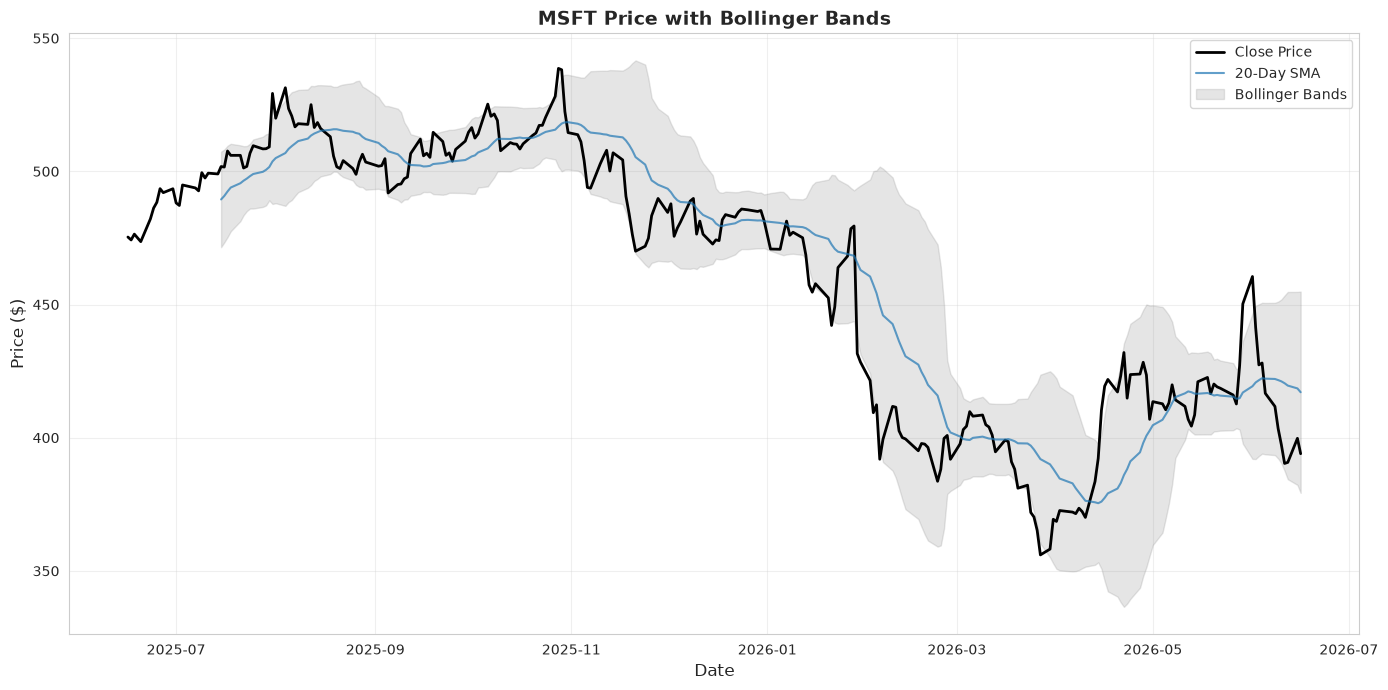

In [4]:
# 1. Price and Bollinger Bands
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(tech_data.index, tech_data['Close'], label='Close Price', color='black', linewidth=2)
ax.plot(tech_data.index, tech_data['SMA'], label='20-Day SMA', alpha=0.7)
ax.fill_between(tech_data.index, tech_data['BB_Upper'], tech_data['BB_Lower'], alpha=0.2, color='gray', label='Bollinger Bands')

ax.set_title(f'{PRIMARY_STOCK} Price with Bollinger Bands', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price ($)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/bollinger_bands.png', dpi=300, bbox_inches='tight')
print('Saved: visualizations/bollinger_bands.png')
plt.show()


Saved: visualizations/rsi.png


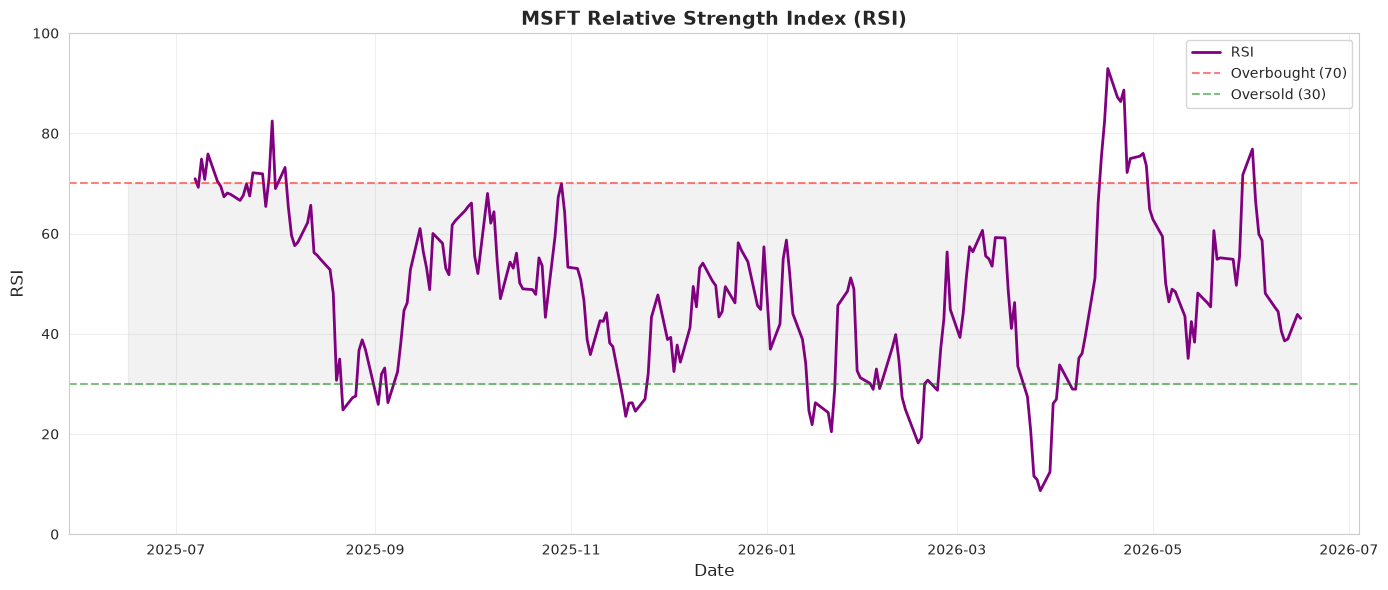

In [5]:
# 2. RSI
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(tech_data.index, tech_data['RSI'], label='RSI', color='purple', linewidth=2)
ax.axhline(y=70, color='r', linestyle='--', alpha=0.5, label='Overbought (70)')
ax.axhline(y=30, color='g', linestyle='--', alpha=0.5, label='Oversold (30)')
ax.fill_between(tech_data.index, 30, 70, alpha=0.1, color='gray')

ax.set_title(f'{PRIMARY_STOCK} Relative Strength Index (RSI)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('RSI', fontsize=12)
ax.set_ylim(0, 100)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/rsi.png', dpi=300, bbox_inches='tight')
print('Saved: visualizations/rsi.png')
plt.show()


Saved: visualizations/macd.png


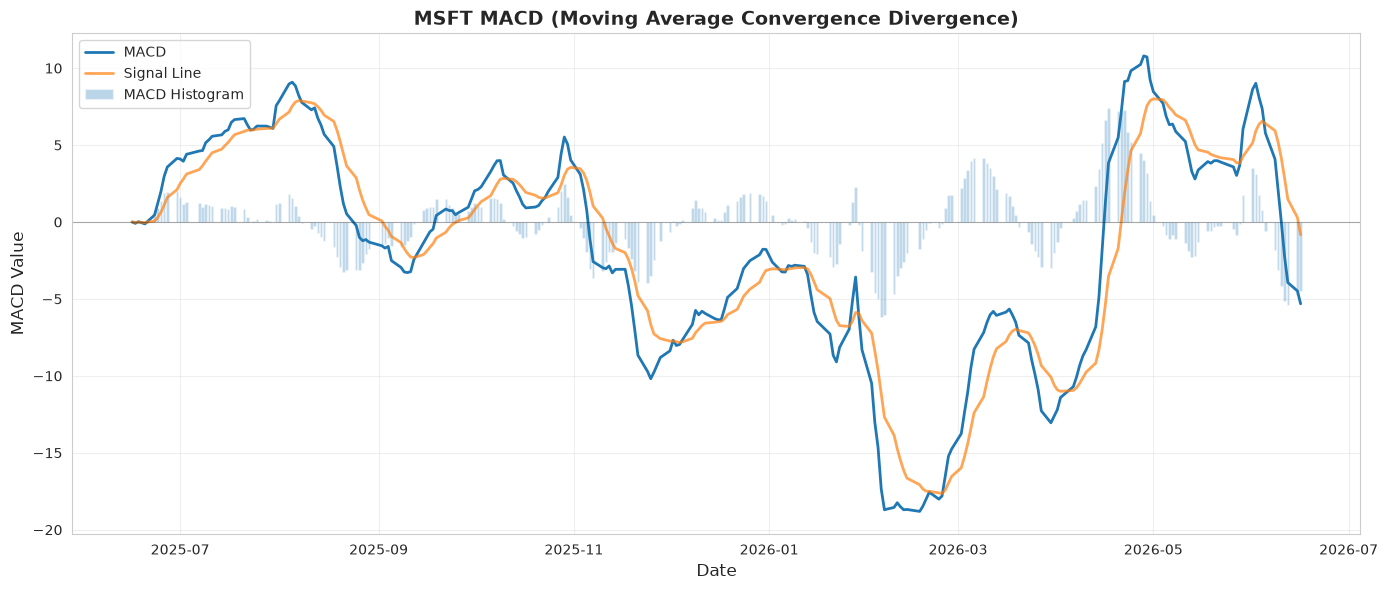

In [6]:
# 3. MACD
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(tech_data.index, tech_data['MACD'], label='MACD', linewidth=2)
ax.plot(tech_data.index, tech_data['Signal_Line'], label='Signal Line', linewidth=2, alpha=0.7)
ax.bar(tech_data.index, tech_data['MACD_Histogram'], label='MACD Histogram', alpha=0.3)
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=0.8)

ax.set_title(f'{PRIMARY_STOCK} MACD (Moving Average Convergence Divergence)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('MACD Value', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/macd.png', dpi=300, bbox_inches='tight')
print('Saved: visualizations/macd.png')
plt.show()


## Trading Signals Analysis

In [7]:
# Generate trading signals based on indicators

# RSI signals
tech_data['RSI_Signal'] = 'NEUTRAL'
tech_data.loc[tech_data['RSI'] > 70, 'RSI_Signal'] = 'OVERBOUGHT'
tech_data.loc[tech_data['RSI'] < 30, 'RSI_Signal'] = 'OVERSOLD'

# MACD signals
tech_data['MACD_Signal'] = 'NEUTRAL'
tech_data.loc[tech_data['MACD'] > tech_data['Signal_Line'], 'MACD_Signal'] = 'BUY'
tech_data.loc[tech_data['MACD'] < tech_data['Signal_Line'], 'MACD_Signal'] = 'SELL'

# Bollinger Bands signals
tech_data['BB_Signal'] = 'NEUTRAL'
tech_data.loc[tech_data['Close'] > tech_data['BB_Upper'], 'BB_Signal'] = 'OVERBOUGHT'
tech_data.loc[tech_data['Close'] < tech_data['BB_Lower'], 'BB_Signal'] = 'OVERSOLD'

# Print recent signals
print('\n' + '='*80)
print('RECENT TRADING SIGNALS (Last 10 Days)')
print('='*80)

recent_signals = tech_data[['Close', 'RSI', 'RSI_Signal', 'MACD_Signal', 'BB_Signal']].tail(10)
print(recent_signals.to_string())



RECENT TRADING SIGNALS (Last 10 Days)
                 Close        RSI RSI_Signal MACD_Signal BB_Signal
Date                                                              
2026-06-03  427.339996  59.870382    NEUTRAL         BUY   NEUTRAL
2026-06-04  428.049988  58.627537    NEUTRAL         BUY   NEUTRAL
2026-06-05  416.670013  48.062560    NEUTRAL        SELL   NEUTRAL
2026-06-08  411.739990  45.278570    NEUTRAL        SELL   NEUTRAL
2026-06-09  403.410004  44.421801    NEUTRAL        SELL   NEUTRAL
2026-06-10  397.359985  40.497031    NEUTRAL        SELL   NEUTRAL
2026-06-11  390.339996  38.579481    NEUTRAL        SELL   NEUTRAL
2026-06-12  390.739990  38.934381    NEUTRAL        SELL   NEUTRAL
2026-06-15  399.760010  43.847843    NEUTRAL        SELL   NEUTRAL
2026-06-16  393.989990  43.062973    NEUTRAL        SELL   NEUTRAL


## Signal Statistics

In [8]:
print('\n' + '='*80)
print('SIGNAL STATISTICS')
print('='*80)

# RSI Analysis
print(f'\nRSI Statistics:')
print(f'  Mean RSI: {tech_data["RSI"].mean():.2f}')
print(f'  Current RSI: {tech_data["RSI"].iloc[-1]:.2f}')
overbought_count = (tech_data['RSI'] > 70).sum()
oversold_count = (tech_data['RSI'] < 30).sum()
print(f'  Overbought periods: {overbought_count} ({overbought_count/len(tech_data)*100:.1f}%)')
print(f'  Oversold periods: {oversold_count} ({oversold_count/len(tech_data)*100:.1f}%)')

# MACD Analysis
print(f'\nMACD Signals:')
buy_signals = (tech_data['MACD_Signal'] == 'BUY').sum()
sell_signals = (tech_data['MACD_Signal'] == 'SELL').sum()
print(f'  Buy signals: {buy_signals}')
print(f'  Sell signals: {sell_signals}')

# Bollinger Bands Analysis
print(f'\nBollinger Bands:')
bb_overbought = (tech_data['BB_Signal'] == 'OVERBOUGHT').sum()
bb_oversold = (tech_data['BB_Signal'] == 'OVERSOLD').sum()
print(f'  Price above upper band: {bb_overbought} times')
print(f'  Price below lower band: {bb_oversold} times')



SIGNAL STATISTICS

RSI Statistics:
  Mean RSI: 48.61
  Current RSI: 43.06
  Overbought periods: 23 (9.1%)
  Oversold periods: 34 (13.5%)

MACD Signals:
  Buy signals: 128
  Sell signals: 123

Bollinger Bands:
  Price above upper band: 13 times
  Price below lower band: 14 times


## Key Insights from Technical Analysis

In [9]:
print('\n' + '='*80)
print('TECHNICAL ANALYSIS INSIGHTS')
print('='*80)

current_rsi = tech_data['RSI'].iloc[-1]
current_price = tech_data['Close'].iloc[-1]
current_bb_upper = tech_data['BB_Upper'].iloc[-1]
current_bb_lower = tech_data['BB_Lower'].iloc[-1]

print(f'\n1. Current Market Status (Latest Data Point):')
print(f'   - Price: ${current_price:.2f}')
print(f'   - RSI: {current_rsi:.2f}', end='')
if current_rsi > 70:
    print(' (OVERBOUGHT)')
elif current_rsi < 30:
    print(' (OVERSOLD)')
else:
    print(' (NEUTRAL)')

print(f'\n2. Bollinger Bands Position:')
print(f'   - Upper Band: ${current_bb_upper:.2f}')
print(f'   - Price: ${current_price:.2f}')
print(f'   - Lower Band: ${current_bb_lower:.2f}')

print(f'\n3. Trading Recommendations:')
print(f'   - RSI can indicate reversal points')
print(f'   - MACD shows momentum changes')
print(f'   - Bollinger Bands indicate volatility')
print(f'   - Use multiple indicators for confirmation')

print('\n✅ Technical analysis complete!')



TECHNICAL ANALYSIS INSIGHTS

1. Current Market Status (Latest Data Point):
   - Price: $393.99
   - RSI: 43.06 (NEUTRAL)

2. Bollinger Bands Position:
   - Upper Band: $454.86
   - Price: $393.99
   - Lower Band: $379.29

3. Trading Recommendations:
   - RSI can indicate reversal points
   - MACD shows momentum changes
   - Bollinger Bands indicate volatility
   - Use multiple indicators for confirmation

✅ Technical analysis complete!
